<a href="https://colab.research.google.com/github/baubyte/CienciaDeDatos/blob/main/series_temporales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Series temporales: de la descomposición al forecasting
### Dataset: ventas mensuales de una cadena de retail argentina (2015–2023)

Este notebook recorre los conceptos centrales de la unidad en orden: primero entendemos la estructura de la serie, después la descomponemos, y finalmente aplicamos modelos para proyectar valores futuros.

---

## Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# seasonal_decompose: descomposición clásica (tendencia + estacionalidad + residuo)
# STL: descomposición robusta, mejor ante valores extremos
from statsmodels.tsa.seasonal import seasonal_decompose, STL

# SimpleExpSmoothing: suavizado exponencial simple (SES) — solo nivel
# ExponentialSmoothing: Holt (doble) y Holt-Winters (triple) — nivel + tendencia + estacionalidad
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# SARIMAX: modelo ARIMA con componente estacional — para forecasting con autocorrelaciones
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prophet: modelo de forecasting de Meta — tendencia + estacionalidad + feriados
from prophet import Prophet

# Suprime warnings de convergencia que aparecen durante el ajuste de SARIMA
import warnings
warnings.filterwarnings('ignore')

Períodos: 108 meses (2015-01 → 2023-12)


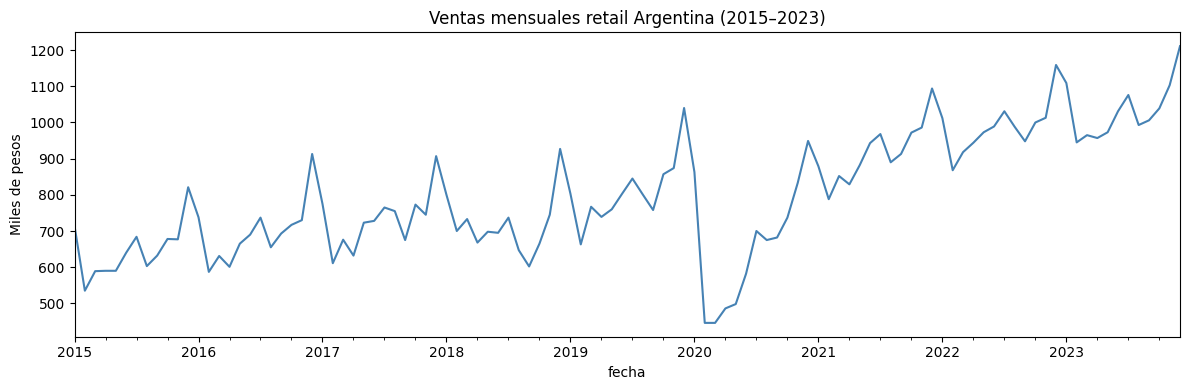

In [ ]:
# Cargar y preparar el dataset
df = pd.read_csv('ventas_retail_argentina.csv')
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.set_index('fecha')

# Serie principal como variable independiente para mayor claridad
serie = df['ventas_miles_pesos']

print(f'Períodos: {len(serie)} meses ({serie.index[0].strftime("%Y-%m")} → {serie.index[-1].strftime("%Y-%m")})')
serie.plot(figsize=(12, 4), title='Ventas mensuales retail Argentina (2015–2023)',
           ylabel='Miles de pesos', color='steelblue')
plt.tight_layout()
plt.show()

> **Antes de seguir, observar en el gráfico:**
> - ¿Hay una dirección general de crecimiento? → **tendencia**
> - ¿Hay picos que se repiten en los mismos meses cada año? → **estacionalidad**
> - ¿Hay algún evento brusco que rompe el patrón? → **residuo / ruido**

---

## 1. Los tres componentes de una serie temporal

Toda serie temporal puede descomponerse en:

```
Yₜ = Tendencia-ciclo  +  Estacionalidad  +  Residuo
     (Trend-cycle)        (Seasonality)      (Remainder)
```

**Tendencia-ciclo *(trend-cycle)*:** la dirección de largo plazo. Puede ser creciente, decreciente o con quiebres.

**Estacionalidad *(seasonality)*:** patrón que se repite con período fijo y conocido. En datos mensuales de retail, el pico suele ser diciembre (Navidad) y el valle febrero.

**Residuo *(remainder)*:** lo que no explican los otros dos. Incluye ruido aleatorio y eventos extraordinarios como el COVID.

**Descomposición aditiva vs. multiplicativa:**
- **Aditiva:** `Yₜ = T + S + R` — cuando la amplitud de la estacionalidad es constante en el tiempo.
- **Multiplicativa:** `Yₜ = T × S × R` — cuando la estacionalidad crece junto con el nivel de la serie.

---

## 2. Descomposición clásica

La descomposición clásica es más rígida: supone que el patrón estacional es exactamente igual todos los años. Si en 2015 diciembre sube 200 unidades sobre el nivel esperado, asume que en 2020 también sube exactamente 200. Además, como usa una media móvil centrada para estimar la tendencia, no puede calcular los primeros y últimos 6 valores — esos quedan como NaN.

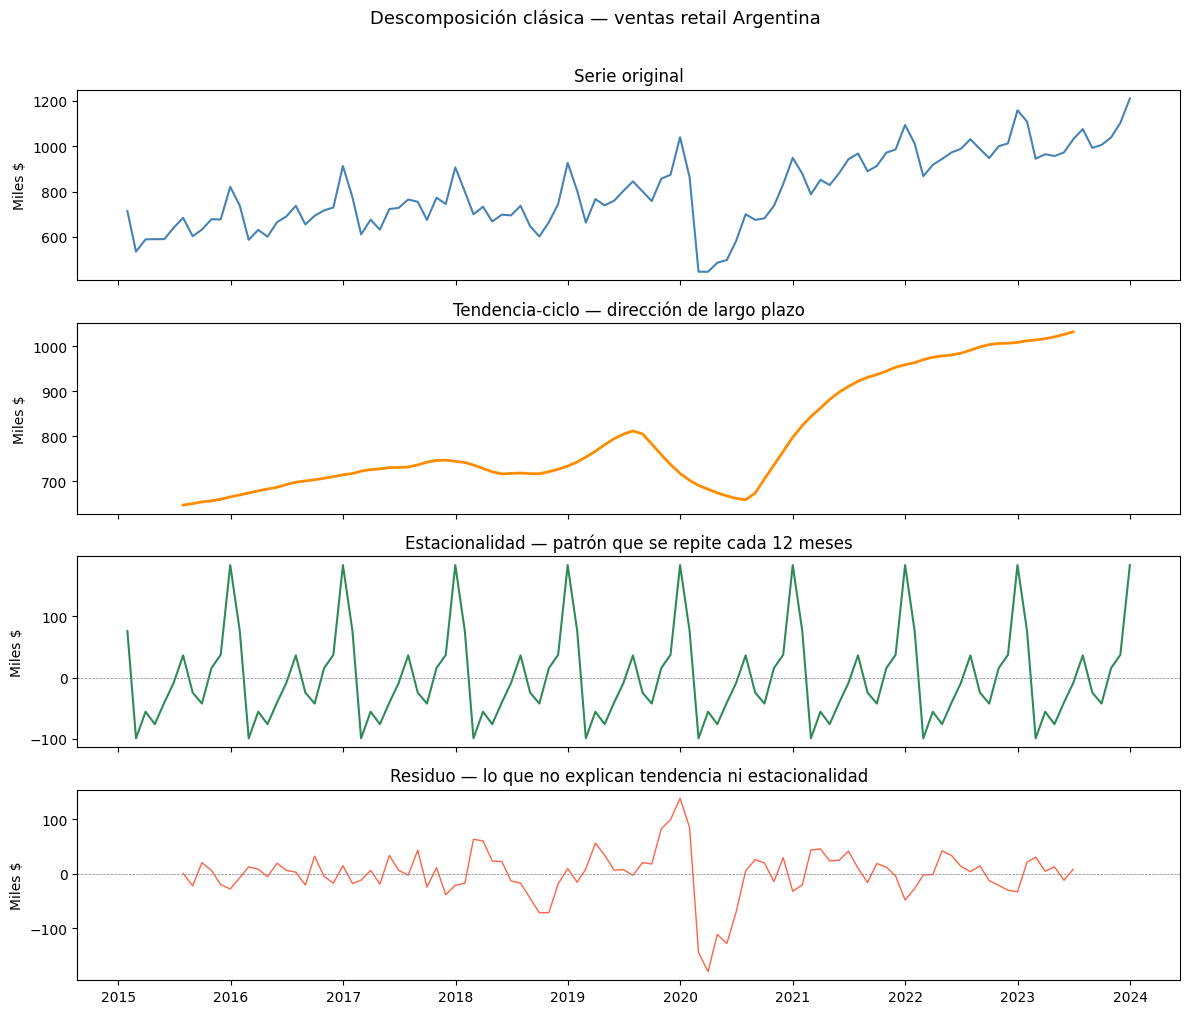

In [ ]:
# Internamente usa una media móvil centrada para estimar la tendencia,
# por eso los primeros y últimos 6 valores quedan como NaN.
descomp = seasonal_decompose( #descompone la serie en tendencia, estacionalidad y residuo.
    serie,
    model='additive',   # T + S + R (usar 'multiplicative' si la estacionalidad crece con el nivel)
    period=12           # duración del ciclo estacional: 12 meses = 1 año
)

# Cuatro paneles apilados que comparten el mismo eje x
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(serie, color='steelblue', linewidth=1.5)
axes[0].set_title('Serie original')

axes[1].plot(descomp.trend, color='darkorange', linewidth=2)
axes[1].set_title('Tendencia-ciclo — dirección de largo plazo')

axes[2].plot(descomp.seasonal, color='seagreen', linewidth=1.5)
axes[2].axhline(0, color='gray', linewidth=0.5, linestyle='--')  # línea de referencia en cero
axes[2].set_title('Estacionalidad — patrón que se repite cada 12 meses')

axes[3].plot(descomp.resid, color='tomato', linewidth=1)
axes[3].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[3].set_title('Residuo — lo que no explican tendencia ni estacionalidad')

for ax in axes:
    ax.set_ylabel('Miles $')

plt.suptitle('Descomposición clásica — ventas retail Argentina', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

> **¿Qué muestra cada panel?**
>
> - **Tendencia:** crecimiento 2015–2017, freno en la crisis 2018, caída COVID 2020, recuperación hasta 2023.
> - **Estacionalidad:** diciembre suma ventas (Navidad), febrero resta. El patrón es idéntico cada año — la descomposición clásica lo supone fijo, lo cual es una limitación.
> - **Residuo:** los eventos fuera del patrón regular. El COVID aparece acá como un residuo muy negativo en 2020.
>
> **Limitación de la descomposición clásica:** los primeros y últimos 6 valores de la tendencia son `NaN` porque usa una media móvil centrada que necesita datos a ambos lados de cada punto.

---

## 3. Descomposición STL — más robusta

STL es más flexible: permite que la estacionalidad cambie gradualmente en el tiempo. Y con robust=True tiene una ventaja adicional — los valores extremos como el COVID quedan absorbidos por el residuo sin contaminar la tendencia estimada. Tampoco genera NaN en los extremos.


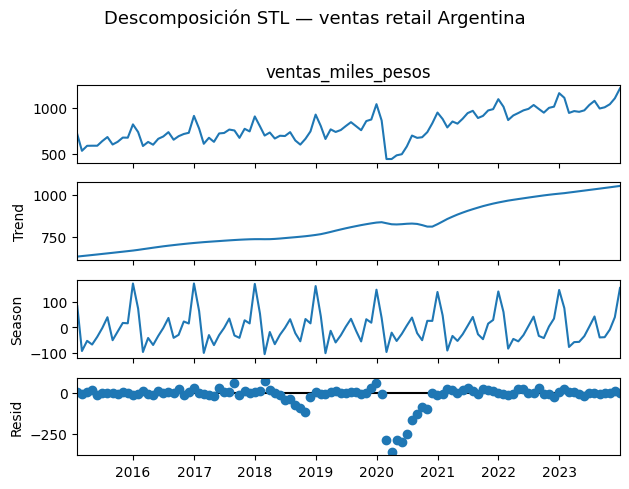

In [ ]:
# serie: la que se va a descomponer.
# period=12: el ciclo estacional dura 12 meses.
# robust=True: activa la estimación robusta — los valores extremos
#              (como el COVID) afectan solo al residuo y no distorsionan
#              la tendencia ni la estacionalidad estimadas.
stl = STL(serie, period=12, robust=True)
resultado_stl = stl.fit() #ejecuta el algoritmo y devuelve el resultado con los tres componentes.

resultado_stl.plot()
plt.suptitle('Descomposición STL — ventas retail Argentina', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

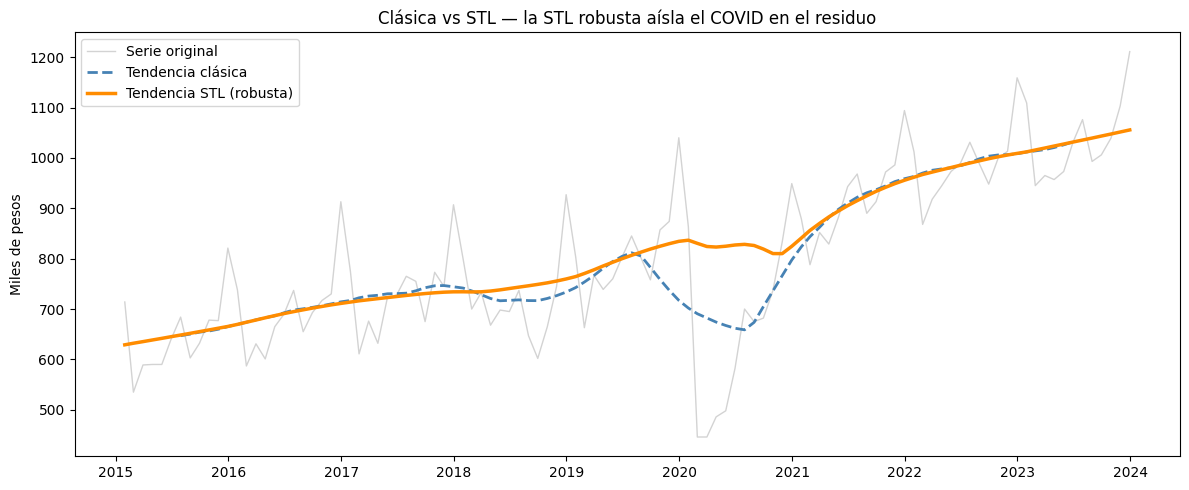

In [ ]:
# Comparar la tendencia clásica vs STL para ver el efecto de la robustez
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(serie,                color='lightgray',   linewidth=1,   label='Serie original')
ax.plot(descomp.trend,        color='steelblue',   linewidth=2,   label='Tendencia clásica', linestyle='--')
ax.plot(resultado_stl.trend,  color='darkorange',  linewidth=2.5, label='Tendencia STL (robusta)')

ax.set_title('Clásica vs STL — la STL robusta aísla el COVID en el residuo')
ax.set_ylabel('Miles de pesos')
ax.legend()
plt.tight_layout()
plt.show()

> **Para observar:** La tendencia STL (naranja) cae más gradualmente durante el COVID que la clásica (azul). Eso ocurre porque `robust=True` hace que el impacto puntual del cierre quede absorbido por el residuo, sin contaminar la tendencia estructural.
>
> Para tomar decisiones de largo plazo — ¿el negocio se recuperó estructuralmente? — la tendencia STL es más informativa.

---

## 4. Familia de suavizado exponencial

Los métodos de suavizado exponencial parten de una idea simple: los datos recientes son más relevantes que los antiguos. Los pesos decaen exponencialmente hacia el pasado.

La familia tiene tres niveles, cada uno agrega un componente:

| Método | Componentes que modela | Parámetros |
|---|---|---|
| SES — Simple | Solo el nivel actual | α |
| Holt — Doble | Nivel + tendencia | α, β |
| Holt-Winters — Triple | Nivel + tendencia + estacionalidad | α, β, γ |

**A diferencia del promedio móvil, estos métodos generan pronósticos hacia el futuro.**

Vamos a entrenar con 2015–2021 y pronosticar 2022–2023 para comparar contra los valores reales.

In [ ]:
# Dividir en entrenamiento y prueba
train = serie.loc[:'2021-12-01'] #filtra por el índice temporal, desde el inicio hasta diciembre 2021 inclusive
test  = serie.loc['2022-01-01':] # desde enero 2022 hasta el final de la serie, valores reales para comparar

print(f'Entrenamiento: {len(train)} meses | Prueba: {len(test)} meses')

In [ ]:
# ── SES: Suavizado Exponencial Simple ────────────────────────────────────────
# Útil solo para series sin tendencia ni estacionalidad clara
# .fit() estima α automáticamente minimizando el error
modelo_ses = SimpleExpSmoothing(train).fit()
fc_ses = modelo_ses.forecast(len(test))

print(f'SES  — alpha: {modelo_ses.params["smoothing_level"]:.3f}')

In [ ]:
# ── Holt: Suavizado Exponencial Doble ────────────────────────────────────────
# Agrega la tendencia. trend='add': tendencia aditiva
modelo_holt = ExponentialSmoothing(train, trend='add', seasonal=None).fit()
fc_holt = modelo_holt.forecast(len(test))


print(f'Holt — alpha: {modelo_holt.params["smoothing_level"]:.3f}  beta: {modelo_holt.params["smoothing_trend"]:.3f}')


In [ ]:
# ── Holt-Winters: Suavizado Exponencial Triple ───────────────────────────────
# Agrega la estacionalidad. seasonal='add': estacionalidad aditiva
# seasonal_periods=12: el ciclo dura 12 meses
modelo_hw = ExponentialSmoothing(
    train, trend='add', seasonal='add', seasonal_periods=12
).fit()
fc_hw = modelo_hw.forecast(len(test))

print(f'HW   — alpha: {modelo_hw.params["smoothing_level"]:.3f}  beta: {modelo_hw.params["smoothing_trend"]:.3f}  gamma: {modelo_hw.params["smoothing_seasonal"]:.3f}')

In [ ]:
# Comparar los tres modelos contra los valores reales
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(train,   color='steelblue',  linewidth=1.5, label='Entrenamiento (2015–2021)')
ax.plot(test,    color='black',      linewidth=1.5, label='Real (2022–2023)', linestyle=':')
ax.plot(fc_ses,  color='tomato',     linewidth=1.5, label='SES — sin tendencia ni estacionalidad', linestyle=':')
ax.plot(fc_holt, color='seagreen',   linewidth=1.5, label='Holt — con tendencia', linestyle='--')
ax.plot(fc_hw,   color='darkorange', linewidth=2.5, label='Holt-Winters — con tendencia y estacionalidad')

# Línea vertical que separa entrenamiento de pronóstico
ax.axvline(pd.Timestamp('2022-01-01'), color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.text(pd.Timestamp('2022-02-01'), train.min() + 30, 'inicio\npronóstico', fontsize=9, color='gray')

ax.set_title('SES vs Holt vs Holt-Winters — cada modelo agrega un componente')
ax.set_ylabel('Miles de pesos')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

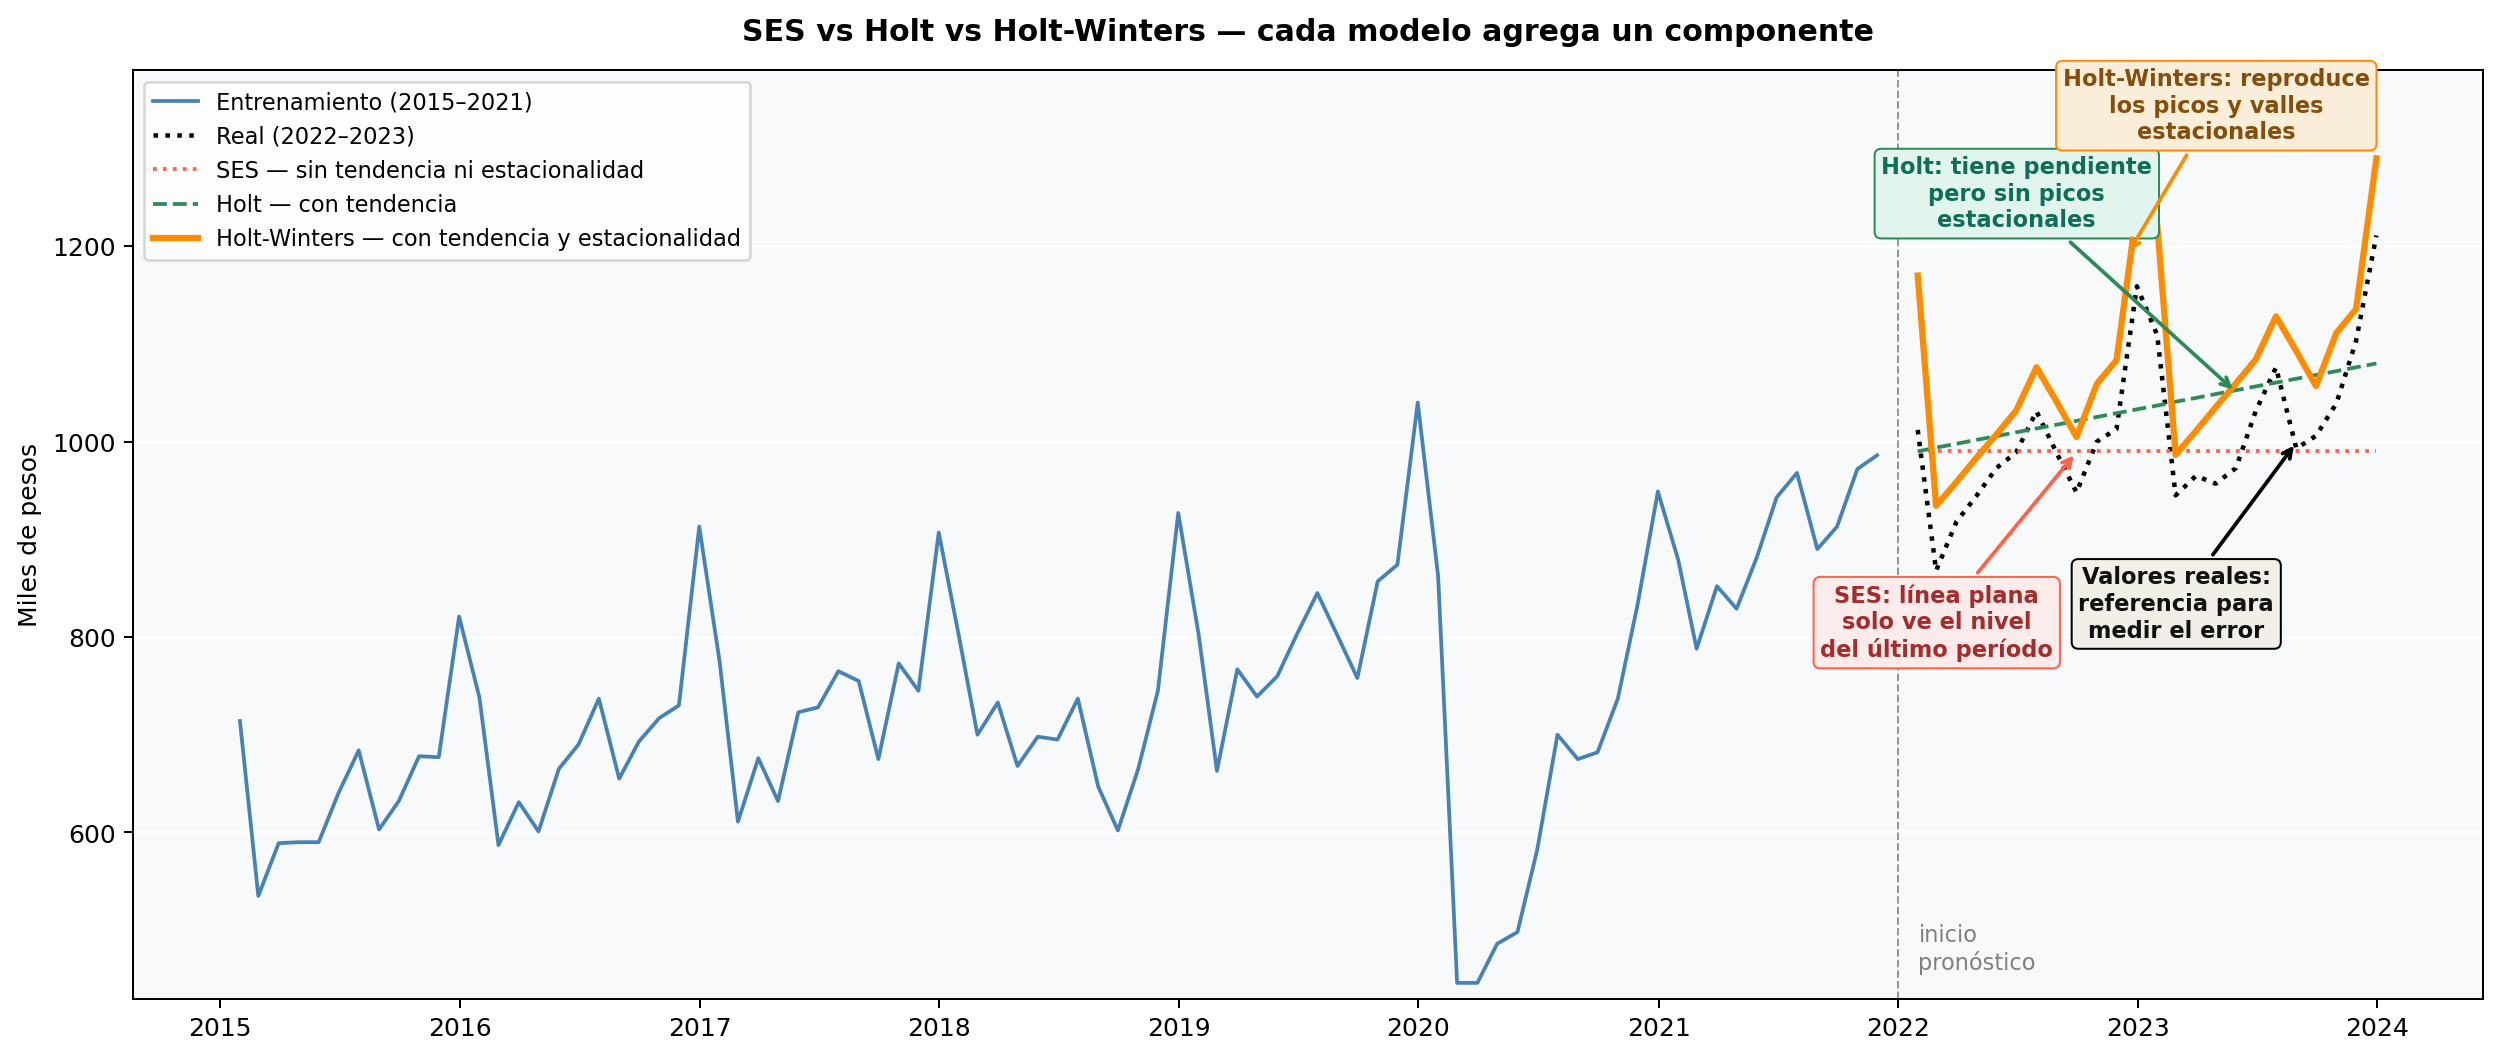

> **Para observar:**
> - **SES** proyecta una línea plana — no ve tendencia ni estacionalidad.
> - **Holt** proyecta con pendiente — capta la dirección de crecimiento pero sin los picos de diciembre.
> - **Holt-Winters** es el único que reproduce los picos y valles estacionales. Es el más cercano a los valores reales.
>
> Cada modelo agrega un componente sobre el anterior. La elección depende de qué tiene la serie.

---

## 5. Estacionariedad y diferenciación — base de ARIMA

Una serie es **estacionaria *(stationary)*** cuando sus propiedades estadísticas (media, varianza) no cambian en el tiempo. Los modelos ARIMA requieren estacionariedad.

La **diferenciación *(differencing)*** convierte una serie no estacionaria en estacionaria: en lugar de modelar los valores absolutos, se modelan las diferencias entre períodos consecutivos.

In [ ]:
#primera diferencia resta cada valor con el anterior (t - t-1)
diff_1  = serie.diff(1)  #elimina la tendencia
#reesta cada valor con el del mismo mes del año anterior (t - t-12)
diff_12 = serie.diff(12) #elimina la estacionalidad anual

#aplica primero diff(1) y luego diff(12) sobre el resultado
diff_combinada = serie.diff(1).diff(12)  # ambas diferencias aplicadas

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(serie,          color='steelblue', linewidth=1.5)
axes[0].set_title('Serie original — no estacionaria (tiene tendencia y estacionalidad)')

axes[1].plot(diff_1,         color='seagreen',  linewidth=1.2)
axes[1].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[1].set_title('Primera diferencia diff(1) — elimina la tendencia')

axes[2].plot(diff_12,        color='darkorange', linewidth=1.2)
axes[2].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[2].set_title('Diferencia estacional diff(12) — elimina la estacionalidad anual')

axes[3].plot(diff_combinada, color='mediumpurple', linewidth=1.2)
axes[3].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[3].set_title('Diferencia combinada diff(1).diff(12) — más cercana a la estacionariedad')

for ax in axes:
    ax.set_ylabel('Diferencia')

plt.suptitle('Diferenciación para lograr estacionariedad', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

> **Para observar:**
> - La serie original tiene una pendiente clara — no es estacionaria.
> - Después de `diff(1)` la tendencia desaparece pero aún se ven los ciclos estacionales.
> - Después de `diff(12)` la estacionalidad desaparece pero queda la tendencia.
> - La diferencia combinada es más parecida a ruido blanco — fluctúa alrededor del cero sin patrón visible. Eso es lo que ARIMA necesita.

---

## 6. ARIMA y SARIMA

**ARIMA *(AutoRegressive Integrated Moving Average)*** combina tres mecanismos:

- **AR (p):** la serie se predice con sus propios valores pasados.
- **I (d):** número de diferencias para lograr estacionariedad.
- **MA (q):** los errores de predicción pasados también se usan como predictores.

**SARIMA** extiende ARIMA con términos estacionales: `ARIMA(p,d,q)(P,D,Q)ₘ`
- Las mayúsculas (P, D, Q) son los mismos mecanismos pero sobre el componente estacional.
- m es el período estacional (12 para datos mensuales).

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(1,1,1):
# p=1: usa el valor del mes anterior como predictor autorregresivo
# d=1: aplica una diferencia para eliminar la tendencia
# q=1: incorpora el error del mes anterior al modelo
# disp=False: suprime la salida del optimizador durante el ajuste
modelo_arima = ARIMA(train, order=(1, 1, 1)).fit()

# .forecast(n) genera n períodos de pronóstico hacia adelante
fc_arima = modelo_arima.forecast(steps=len(test))


In [ ]:
# Comparar ARIMA vs valores reales
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(train,      color='steelblue',    linewidth=1.5, label='Entrenamiento (2015–2021)')
ax.plot(test,       color='black',        linewidth=1.5, label='Real (2022–2023)', linestyle=':')
ax.plot(fc_arima,   color='mediumpurple', linewidth=2,   label='ARIMA(1,1,1)')

ax.axvline(pd.Timestamp('2022-01-01'), color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.text(pd.Timestamp('2022-02-01'), train.min() + 30, 'inicio\npronóstico', fontsize=9, color='gray')

ax.set_title('ARIMA(1,1,1) — captura tendencia pero no estacionalidad')
ax.set_ylabel('Miles de pesos')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(modelo_arima.summary().tables[0])

In [ ]:
# order=(p, d, q) — parte no estacional:
# p=1: usa el valor del mes anterior como predictor autorregresivo
# d=1: aplica una diferencia para eliminar la tendencia
# q=1: incorpora el error del mes anterior al modelo

# seasonal_order=(P, D, Q, m) — parte estacional:
# P=1: autorregresivo estacional — usa el valor del mismo mes del año anterior
# D=1: diferencia estacional — elimina la estacionalidad anual
# Q=1: media móvil estacional — incorpora el error del mismo mes del año anterior
# m=12: el ciclo estacional dura 12 meses (datos mensuales)
modelo_sarima = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
).fit(disp=False)  # disp=False suprime la salida del optimizador

fc_sarima = modelo_sarima.forecast(steps=len(test))

print(modelo_sarima.summary().tables[0])

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(train,      color='steelblue',    linewidth=1.5, label='Entrenamiento (2015–2021)')
ax.plot(test,       color='black',        linewidth=1.5, label='Real (2022–2023)', linestyle=':')
ax.plot(fc_sarima,  color='mediumpurple', linewidth=2.5, label='SARIMA(1,1,1)(1,1,1)₁₂')

ax.axvline(pd.Timestamp('2022-01-01'), color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.text(pd.Timestamp('2022-02-01'), train.min() + 30, 'inicio\npronóstico', fontsize=9, color='gray')

ax.set_title('SARIMA(1,1,1)(1,1,1)₁₂ — pronóstico con componente estacional')
ax.set_ylabel('Miles de pesos')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

> **Para observar:**
> - Ambos capturan la estacionalidad y la tendencia.
> - SARIMA modela las **autocorrelaciones** en los datos — la relación entre cada valor y sus propios valores pasados. Holt-Winters modela explícitamente nivel, tendencia y estacionalidad como componentes separados.
> - No hay un modelo universalmente mejor. Holt-Winters es más interpretable; SARIMA es más flexible para patrones complejos de autocorrelación.

---

## 7. Prophet

Prophet es una biblioteca de Meta que permite hacer forecasting de forma accesible. Modela la serie como:

```
yₜ = g(t) + s(t) + h(t) + εₜ

g(t) → tendencia: lineal por tramos con puntos de cambio (changepoints) automáticos
s(t) → estacionalidad: modelada con series de Fourier
h(t) → efectos de feriados y eventos especiales
εₜ  → residuo
```

**Requisito del input:** un DataFrame con exactamente dos columnas: `ds` (fecha) y `y` (valor).

In [ ]:
# Prophet requiere un DataFrame con columnas 'ds' y 'y'
df_prophet = train.reset_index()
df_prophet.columns = ['ds', 'y']  # renombrar al formato requerido

# Instanciar y ajustar el modelo
# yearly_seasonality=True: activa la estacionalidad anual
# weekly_seasonality=False: datos mensuales, no tiene sentido la estacionalidad semanal
modelo_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
modelo_prophet.fit(df_prophet)

In [ ]:
# make_future_dataframe genera el DataFrame de fechas para el pronóstico
# periods=24: 24 meses hacia adelante
# freq='ME': frecuencia mensual
futuro = modelo_prophet.make_future_dataframe(periods=24, freq='ME')
forecast = modelo_prophet.predict(futuro)

# El resultado tiene columnas:
# yhat: pronóstico
# yhat_lower / yhat_upper: intervalos de incertidumbre
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6)

In [ ]:
# plot() muestra la serie de entrenamiento + el pronóstico con su banda de incertidumbre
fig = modelo_prophet.plot(forecast)
plt.title('Prophet — pronóstico con intervalos de incertidumbre')
plt.ylabel('Miles de pesos')
plt.tight_layout()
plt.show()

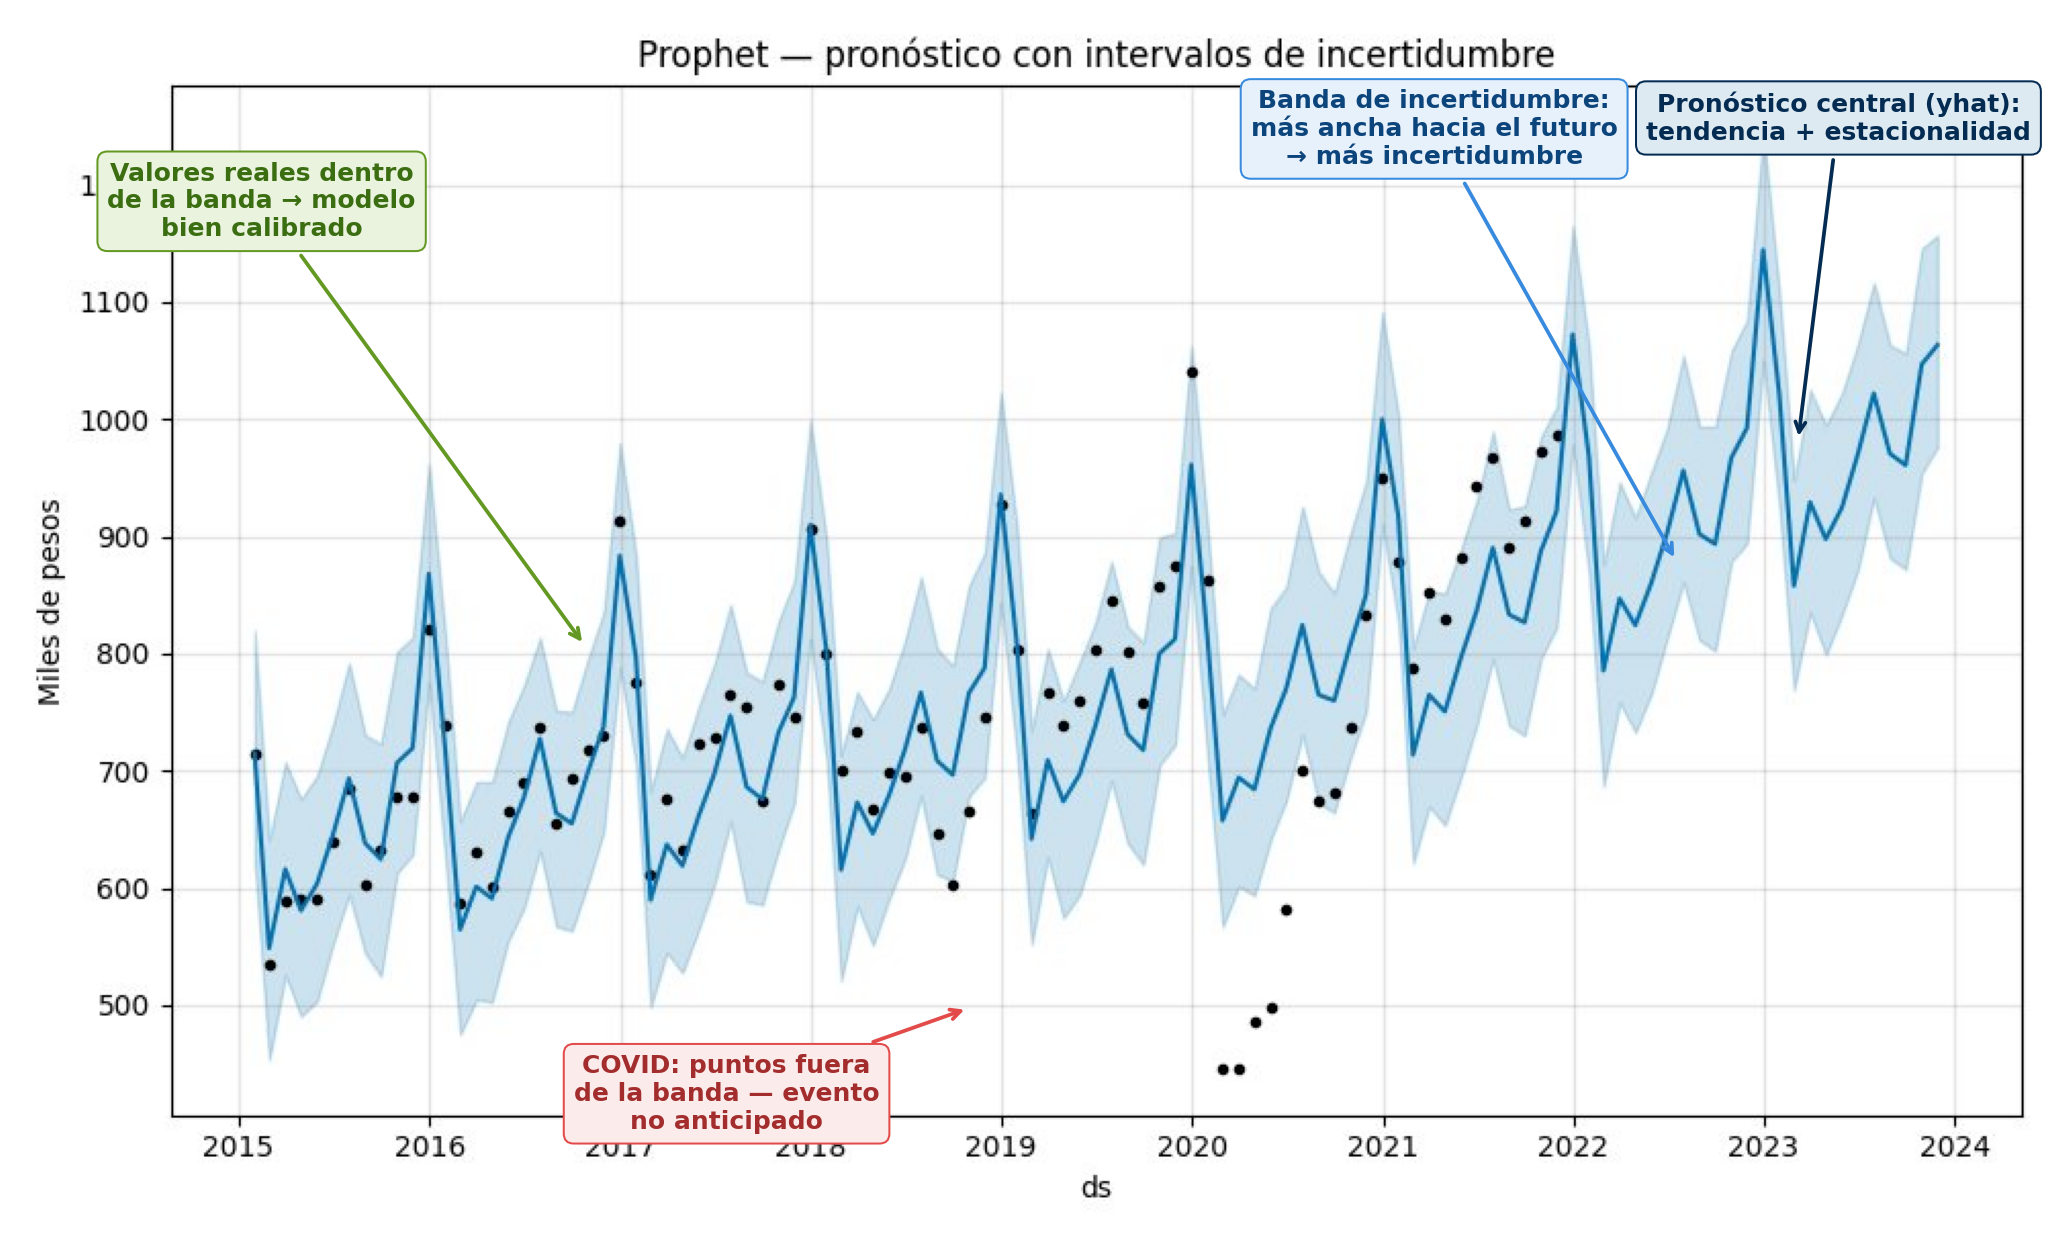

In [ ]:
# plot_components() descompone el pronóstico en sus partes:
# tendencia, estacionalidad anual (y semanal si aplica)
fig = modelo_prophet.plot_components(forecast)
plt.tight_layout()
plt.show()

> **Para observar en plot_components():**
> - **Tendencia:** muestra los puntos de cambio automáticos — dónde el modelo detectó que la tasa de crecimiento cambió.
> - **Estacionalidad anual:** qué meses suman y cuáles restan respecto al nivel esperado. Debería mostrar el pico de diciembre.

---

---

## Resumen: ¿qué método usar y cuándo?

| Método | Modela | Cuándo usarlo |
|---|---|---|
| `seasonal_decompose` | Separa T + S + R | Entender la estructura antes de modelar |
| STL | Separa T + S + R, robusto | Series con eventos extremos o atípicos |
| SES | Solo nivel | Series estables sin tendencia ni estacionalidad |
| Holt | Nivel + tendencia | Series con crecimiento o caída sostenida |
| Holt-Winters | Nivel + tendencia + estacionalidad | Series con patrón estacional claro |
| SARIMA | Autocorrelaciones + estacionalidad | Patrones de autocorrelación complejos |
| Prophet | Tendencia + estacionalidad + feriados | Forecasting escalable, fácil de interpretar |

> **Distinción clave para no confundirse:**
> - `seasonal_decompose` y STL → **diagnóstico** — no predicen, separan componentes.
> - SES, Holt, Holt-Winters, SARIMA, Prophet → **forecasting** — generan pronósticos con intervalos de incertidumbre.